In [3]:
!pip install openpyxl cfml_tools --quiet

import pandas as pd
df=pd.read_excel('agricola.xlsx')
df=df.drop(['EMPRESA','PLANTIO','ID'], axis=1)
df_numeric = df.select_dtypes(include='number')
df = df.fillna(df_numeric.mean())
df.to_csv('embrapa.csv')

In [ ]:
df

,REGIAO,ESPÉCIE,FASE,ADITIVO,AREA,ABA_ESP,ABB_ESP,ABC_ESP,ABD_ESP,ABE_ESP,ABF_ESP,ABG_ESP,ABH_ESP,ABI_ESP,ABL_ESP,ABM_ESP
0,SÃO CARLOS,SCS16,5d,B,99.41,85.651529,26.5440,25.40,22.956142,4446.140,29.600000,32.240000,21.770,160.366948,22.929998,12.660000
1,ASSIS,PS321832847,>5d,B,14.08,93.423077,23.9600,31.73,21.738200,181.360,28.230000,31.250000,25.200,132.243947,21.790632,12.750000
2,SÃO CARLOS,PS321832847,fr,E,20.14,85.651529,25.3700,25.51,22.956142,527.071,28.210000,31.090000,25.480,160.366948,22.929998,12.730000
3,MINAS GERAIS,PS321832847,5d,I,21.36,78.260684,27.3397,27.55,22.164190,632.200,31.284342,34.460182,24.000,164.811414,22.125389,12.696000
4,SÃO CARLOS,PS321832847,>5d,E,17.31,85.651529,26.4030,26.21,22.956142,331.977,29.680000,32.230000,26.181,160.366948,22.929998,12.640000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,RIB. PRETO,SCS19005,5d,I,16.79,64.461378,26.7500,25.01,19.738053,263.290,29.730000,32.433395,23.270,159.127400,19.718506,12.550000
7649,GOIAS,SCS19005,4d,C,52.49,73.854532,27.2400,25.56,21.426631,2516.490,30.490000,33.980000,24.100,164.483044,21.431767,12.760000
7650,MATO G. DO SUL,SCS19005,5d,B,55.76,96.842550,26.9300,25.28,24.666993,3724.710,30.030000,32.570000,22.690,160.607903,24.608273,12.530000
7651,RIB. PRETO,SCS19005,1/½,B,28.12,130.782258,28.0564,24.84,31.072154,1926.770,31.240000,33.390000,28.400,170.892612,30.873623,12.628075


In [4]:
print('Número de regiões ',len(df['REGIAO'].unique()))

Número de regiões  11


In [5]:
print('Número de espécies ',len(df['ESPÉCIE'].unique()))

Número de espécies  149


In [6]:
print('Número de fases ',len(df['FASE'].unique()))

Número de fases  9


In [7]:
print('Número de aditivos ',len(df['ADITIVO'].unique()))

Número de aditivos  6


<Axes: ylabel='Density'>

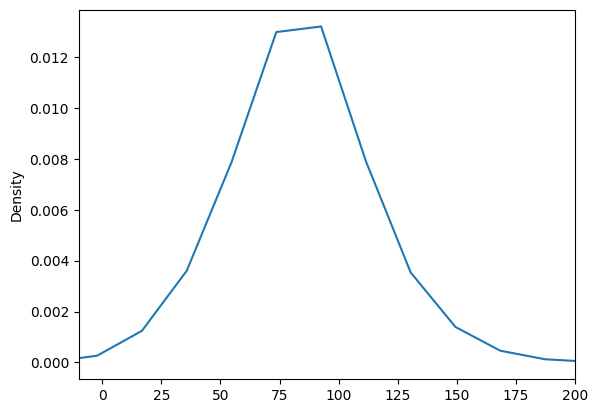

In [8]:
df['ABA_ESP'].plot(kind='kde',xlim=(-10,200))

In [9]:
df1 = df[df['ABA_ESP']<200]

In [10]:
df1['ABA_ESP'].describe()

,ABA_ESP
count,7653.000000
mean,83.876802
std,24.589234
min,12.000000
25%,69.873319
50%,85.651529
75%,94.228971
max,196.330605


In [ ]:
df1.to_csv('embrapa.csv')

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('embrapa.csv')
df=df.drop(['Unnamed: 0'], axis=1)
df.columns

Index(['REGIAO', 'ESPÉCIE', 'FASE', 'ADITIVO', 'AREA', 'ABA_ESP', 'ABB_ESP',
       'ABC_ESP', 'ABD_ESP', 'ABE_ESP', 'ABF_ESP', 'ABG_ESP', 'ABH_ESP',
       'ABI_ESP', 'ABL_ESP', 'ABM_ESP'],
      dtype='object')

In [13]:
df.columns

Index(['REGIAO', 'ESPÉCIE', 'FASE', 'ADITIVO', 'AREA', 'ABA_ESP', 'ABB_ESP',
       'ABC_ESP', 'ABD_ESP', 'ABE_ESP', 'ABF_ESP', 'ABG_ESP', 'ABH_ESP',
       'ABI_ESP', 'ABL_ESP', 'ABM_ESP'],
      dtype='object')

In [22]:
!git clone https://github.com/gdmarmerola/cfml_tools.git
import os
os.chdir('cfml_tools')
!pwd


fatal: destination path 'cfml_tools' already exists and is not an empty directory.
/content/cfml_tools


In [23]:
%%capture
!python setup.py install

[0.29886931 0.33832099 0.322384   0.31711284 0.30788294]


<Axes: title={'center': 'quantidade de frutose'}, xlabel='aditivo'>

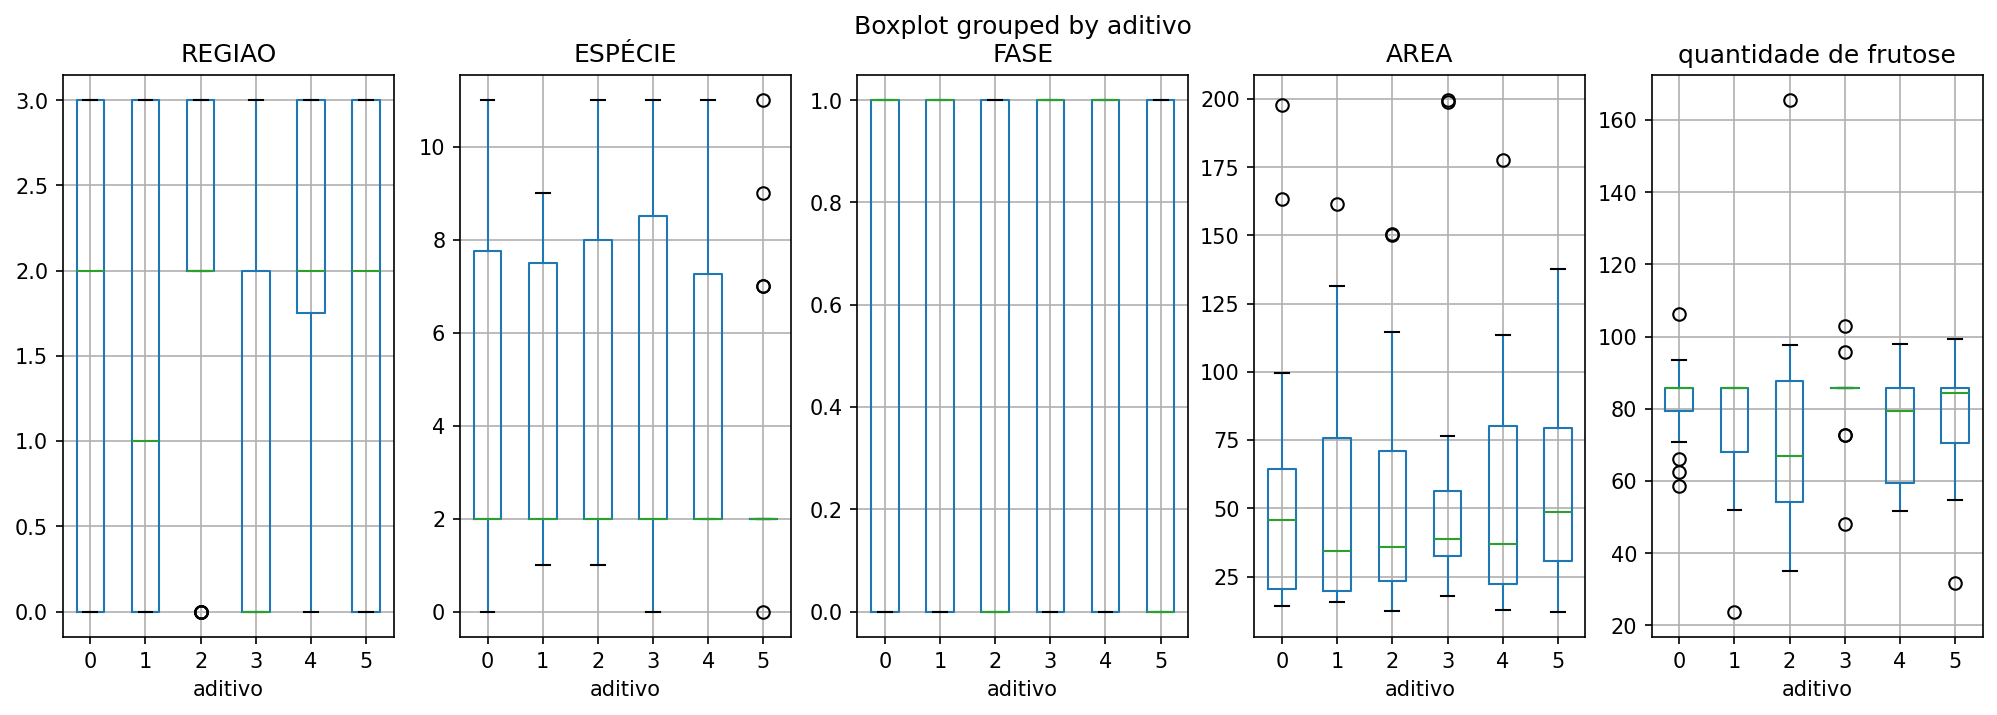

In [39]:
sets = df.copy()
sets[sets.select_dtypes(['object']).columns]= sets[sets.select_dtypes(['object']).columns].apply(lambda x: pd.factorize(x)[0])
sets= sets[sets['AREA']<200]
X = sets[['REGIAO', 'ESPÉCIE', 'FASE', 'AREA']]
W = sets['ADITIVO']
y = sets['ABA_ESP']
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# usar DecisionTreeCounterfactual, árvore de regressão
dtcf = DecisionTreeCounterfactual(save_explanatory=True)
# ajustar modelo aos dados
dtcf.fit(X, W, y)
# prevendo contrafactual
counterfactuals = dtcf.predict(X)
cv_scores = dtcf.get_cross_val_scores(X, y)
print(cv_scores)
test_sample = X.iloc[[0]]
# pegar uma amostra
comparables_table = dtcf.explain(test_sample)
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'quantidade de frutose'})
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('quantidade de frutose','aditivo', ax=ax[4])

## Consolidar e Executar Análise de ABA_ESP

### Subtarefa:
Gerar uma única célula de código que realiza o carregamento dos dados de `agricola.xlsx`, pré-processamento inicial (exclusão de colunas, preenchimento de NaNs), filtragem, engenharia de características (fatoração de variáveis categóricas, definição de X, W, y para `ABA_ESP`), ajuste do modelo `DecisionTreeCounterfactual`, previsão, explicação e geração dos boxplots para `ABA_ESP`. Além disso, calcular e resumir os Efeitos de Tratamento Individual (ITEs) para cada aditivo (1-5)  para `ABA_ESP`.

**Justificativa**:
A subtarefa exige a consolidação de todas as etapas de análise para `ABA_ESP` em uma única célula de código. Isso inclui carregamento de dados, pré-processamento, engenharia de características, ajuste do modelo, previsão, explicação, geração de boxplots e o cálculo e resumo dos Efeitos de Tratamento Individual (ITEs) para cada aditivo .

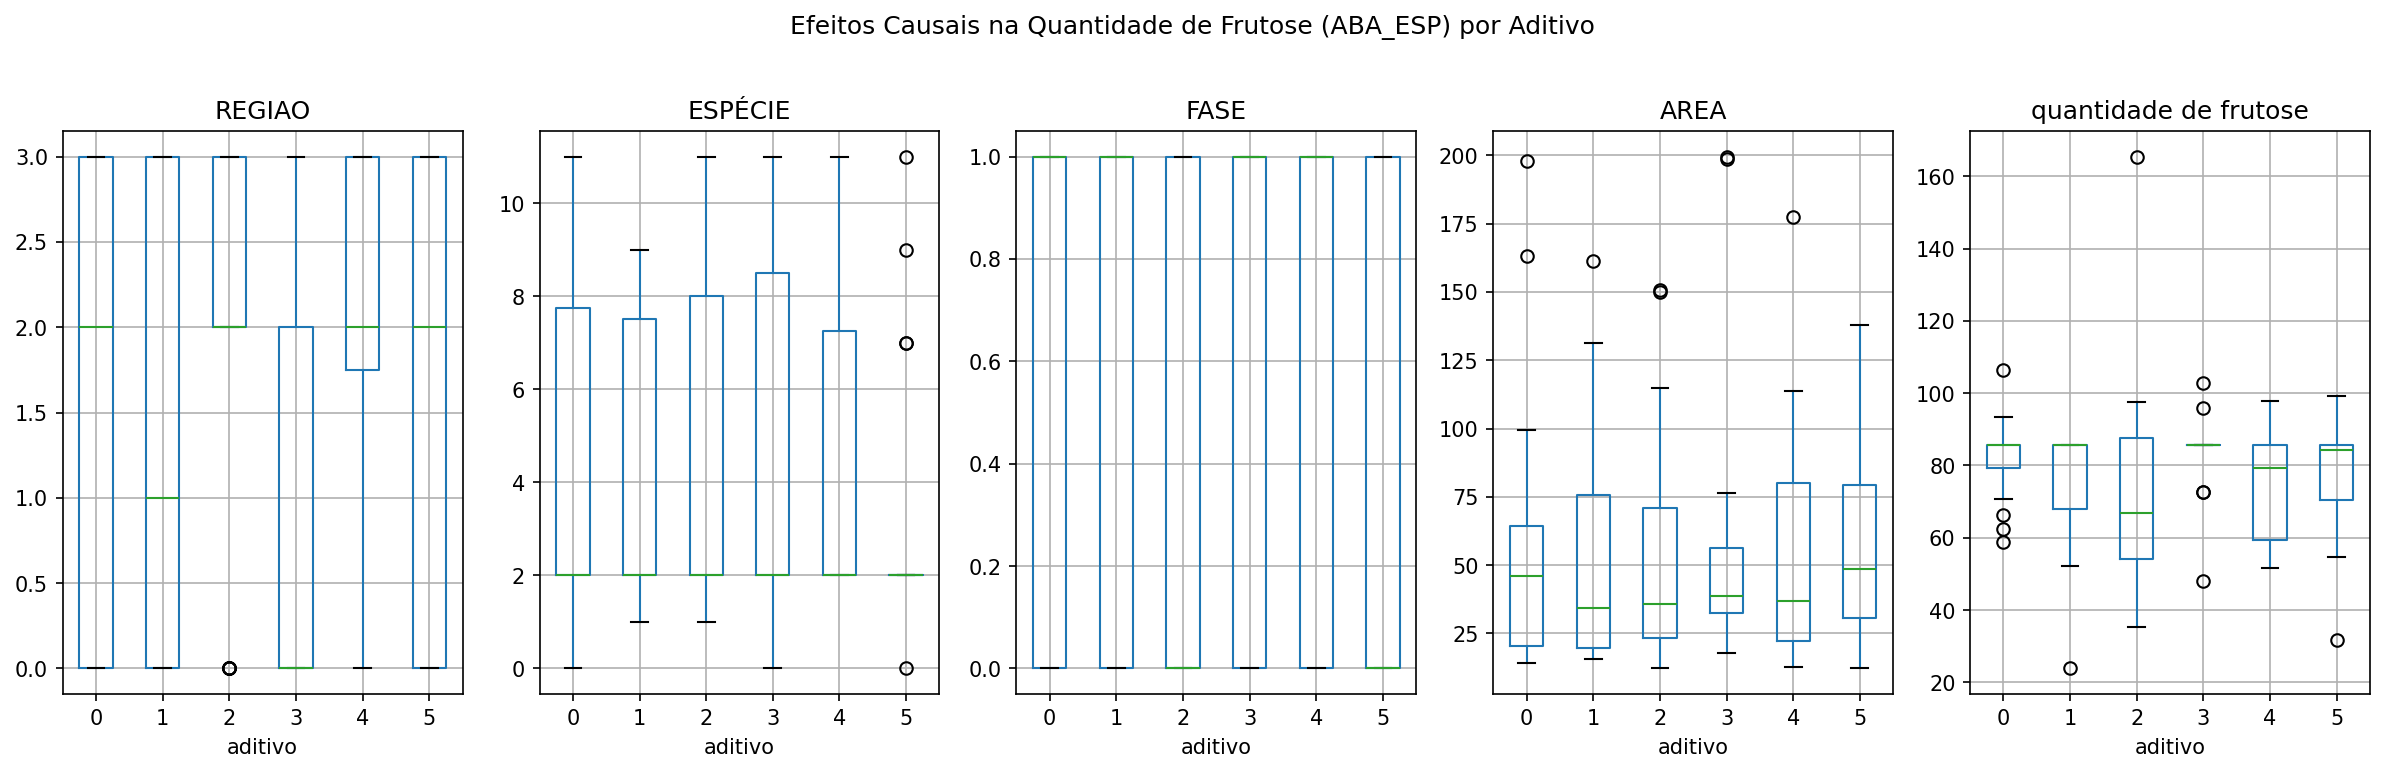


--- Resumo dos Resultados Preditos na ABA_ESP para Cada Aditivo ---

Resultados Preditos para o Aditivo 0:
  Média: 86.83
  Desvio Padrão: 16.76

Resultados Preditos para o Aditivo 1:
  Média: 75.14
  Desvio Padrão: 13.79

Resultados Preditos para o Aditivo 2:
  Média: 88.52
  Desvio Padrão: 17.77

Resultados Preditos para o Aditivo 3:
  Média: 86.94
  Desvio Padrão: 12.57

Resultados Preditos para o Aditivo 4:
  Média: 82.64
  Desvio Padrão: 14.63

Resultados Preditos para o Aditivo 5:
  Média: 83.13
  Desvio Padrão: 14.49


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# 1. Carrega o conjunto de dados agricola.xlsx
df = pd.read_excel('/content/agricola.xlsx')

# 2. Remove colunas
df = df.drop(['EMPRESA','PLANTIO','ID'], axis=1)

# 3. Preenche valores ausentes em colunas numéricas com a média delas
df_numeric = df.select_dtypes(include='number')
df = df.fillna(df_numeric.mean())

# 4. Filtra df para incluir apenas linhas onde 'ABA_ESP' < 200
df = df[df['ABA_ESP'] < 200]

# 5. Cria uma cópia chamada 'sets'
sets = df.copy()

# 6. Fatoriza colunas categóricas em 'sets'
for col in sets.select_dtypes(['object']).columns:
    sets[col] = pd.factorize(sets[col])[0]

# 7. Filtra 'sets' para incluir apenas linhas onde 'AREA' < 200
sets = sets[sets['AREA'] < 200]

# 8. Define X, W, y
X = sets[['REGIAO', 'ESPÉCIE', 'FASE', 'AREA']]
W = sets['ADITIVO']
y = sets['ABA_ESP']

# 9. Instancia e ajusta o modelo DecisionTreeCounterfactual
dtcfsoma = DecisionTreeCounterfactual(save_explanatory=True)
dtcfsoma.fit(X, W, y)

# 10. Prevê contrafactuais
counterfactuals = dtcfsoma.predict(X)

# 11. Cria uma amostra de teste e explica
test_sample = X.iloc[[0]]
comparables_table = dtcfsoma.explain(test_sample)

# 12. Renomeia as colunas em comparables_table
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'quantidade de frutose'})

# 13. Gera boxplots
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('quantidade de frutose','aditivo', ax=ax[4])
plt.suptitle('Efeitos Causais na Quantidade de Frutose (ABA_ESP) por Aditivo', y=1.02)
plt.tight_layout()
plt.show()

# 14. Armazena os resultados previstos para cada aditivo (0 a 5)
sets['predicted_aba_esp_add_0'] = counterfactuals['y_hat'][0].values
sets['predicted_aba_esp_add_1'] = counterfactuals['y_hat'][1].values
sets['predicted_aba_esp_add_2'] = counterfactuals['y_hat'][2].values
sets['predicted_aba_esp_add_3'] = counterfactuals['y_hat'][3].values
sets['predicted_aba_esp_add_4'] = counterfactuals['y_hat'][4].values
sets['predicted_aba_esp_add_5'] = counterfactuals['y_hat'][5].values

# 15. Itera e imprime a média e o desvio padrão para cada resultado predito
print('\n--- Resumo dos Resultados Preditos na ABA_ESP para Cada Aditivo ---')
for i in range(6):
    col_name = f'predicted_aba_esp_add_{i}'
    print(f"\nResultados Preditos para o Aditivo {i}:")
    print(f"  Média: {sets[col_name].mean():.2f}")
    print(f"  Desvio Padrão: {sets[col_name].std():.2f}")

## Analisar Efeitos Causais na Sacarose total recuperável (ABI_ESP)

### Subtarefa:
Reexecutar o modelo `DecisionTreeCounterfactual` com `ABI_ESP` como variável de resultado, calcular os Efeitos de Tratamento Individual (ITEs) para cada aditivo (1-5) em relação ao aditivo 0, e resumir suas médias e desvios padrão. Isso se baseará nos `sets`, `X` e `W` preparados na etapa anterior.

**Justificativa**:
A subtarefa exige a reexecução do modelo `DecisionTreeCounterfactual` com `ABI_ESP` como resultado, o cálculo dos ITEs e seu resumo. Este bloco de código consolida todas as etapas: definição de `y`, ajuste do modelo, previsão de contrafactuais, geração de tabelas de explicação e boxplots, e, finalmente, o cálculo e resumo dos ITEs para cada aditivo em relação ao aditivo 0.

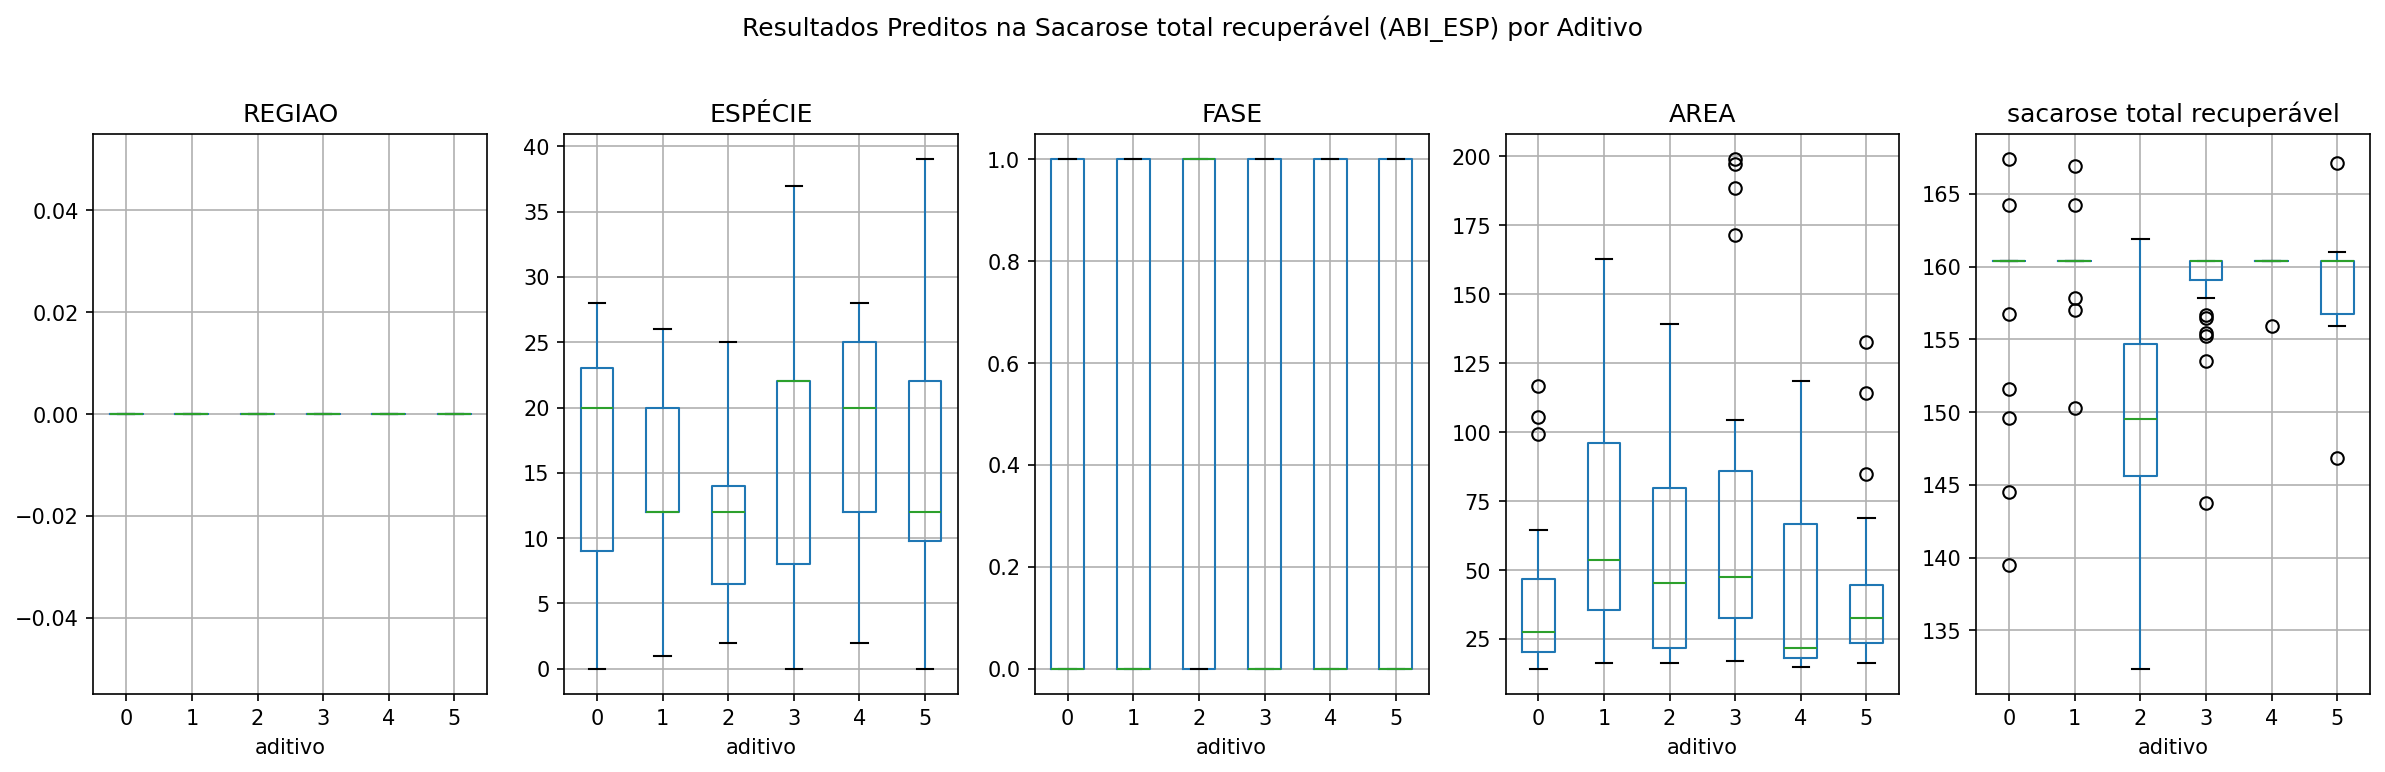


--- Resumo dos Resultados Preditos na ABI_ESP para Cada Aditivo ---

Resultados Preditos para o Aditivo 0:
  Média: 159.99
  Desvio Padrão: 4.04

Resultados Preditos para o Aditivo 1:
  Média: 160.35
  Desvio Padrão: 3.68

Resultados Preditos para o Aditivo 2:
  Média: 160.23
  Desvio Padrão: 3.77

Resultados Preditos para o Aditivo 3:
  Média: 158.66
  Desvio Padrão: 4.54

Resultados Preditos para o Aditivo 4:
  Média: 160.72
  Desvio Padrão: 3.86

Resultados Preditos para o Aditivo 5:
  Média: 160.43
  Desvio Padrão: 3.73


In [44]:
import matplotlib.pyplot as plt
import numpy as np
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# 1. Define a variável alvo y como sets['ABI_ESP']
y = sets['ABI_ESP']

# 2. Instancia um novo modelo DecisionTreeCounterfactual e o ajusta
dtcfsoma = DecisionTreeCounterfactual(save_explanatory=True)
dtcfsoma.fit(X, W, y)

# 3. Prevê contrafactuais
counterfactuals = dtcfsoma.predict(X)

# 4. Seleciona a primeira linha de X como test_sample e usa o método explain() do modelo
test_sample = X.iloc[[0]]
comparables_table = dtcfsoma.explain(test_sample)

# 5. Renomeia as colunas 'W' para 'aditivo' e 'y' para 'sacarose total recuperável'
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'sacarose total recuperável'})

# 6. Gera boxplots
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('sacarose total recuperável','aditivo', ax=ax[4])
plt.suptitle('Resultados Preditos na Sacarose total recuperável (ABI_ESP) por Aditivo', y=1.02)
plt.tight_layout()
plt.show()

# 7. Armazena os resultados previstos para cada aditivo (0 a 5)
sets['predicted_abi_esp_add_0'] = counterfactuals['y_hat'][0].values
sets['predicted_abi_esp_add_1'] = counterfactuals['y_hat'][1].values
sets['predicted_abi_esp_add_2'] = counterfactuals['y_hat'][2].values
sets['predicted_abi_esp_add_3'] = counterfactuals['y_hat'][3].values
sets['predicted_abi_esp_add_4'] = counterfactuals['y_hat'][4].values
sets['predicted_abi_esp_add_5'] = counterfactuals['y_hat'][5].values

# 8. Itera sobre as novas colunas e imprime a média e o desvio padrão
print('\n--- Resumo dos Resultados Preditos na ABI_ESP para Cada Aditivo ---')
for i in range(6):
    col_name = f'predicted_abi_esp_add_{i}'
    print(f"\nResultados Preditos para o Aditivo {i}:")
    print(f"  Média: {sets[col_name].mean():.2f}")
    print(f"  Desvio Padrão: {sets[col_name].std():.2f}")

## Analisar Efeitos Causais na Soma de Resultados

### Subtarefa:
Reexecutar o modelo `DecisionTreeCounterfactual` com a 'soma de resultados' (soma dos parâmetros normalizados) como variável de resultado, calcular os Efeitos de Tratamento Individual (ITEs) para cada aditivo (1-5) , e resumir suas médias e desvios padrão. Isso também se baseará nos `sets`, `X` e `W` da configuração consolidada.

**Justificativa**:
A subtarefa exige a definição de 'soma de resultados' como a nova variável alvo, o reajuste do modelo `DecisionTreeCounterfactual`, a previsão de contrafactuais, a geração de boxplots para efeitos causais, e então o cálculo e resumo dos Efeitos de Tratamento Individual (ITEs) para cada aditivo (1-5) .

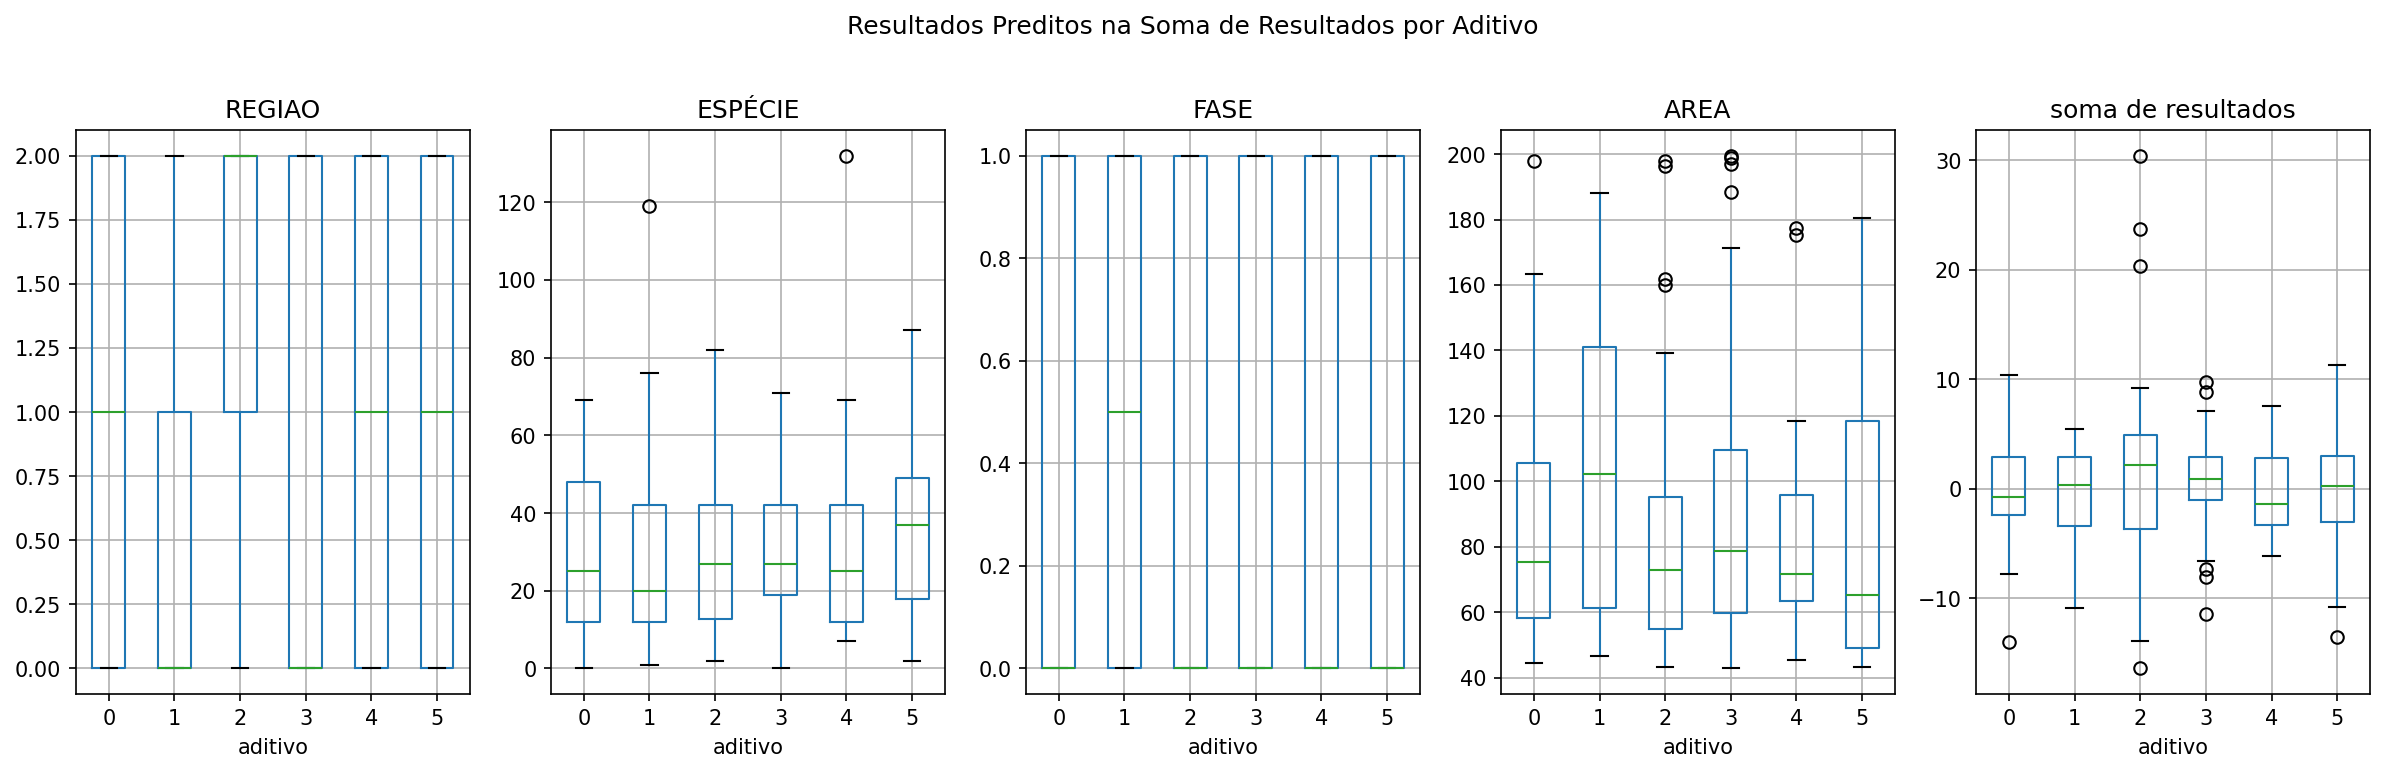


--- Resumo dos Resultados Preditos na Soma de Resultados para Cada Aditivo ---

Resultados Preditos para o Aditivo 0:
  Média: 0.17
  Desvio Padrão: 2.78

Resultados Preditos para o Aditivo 1:
  Média: -0.81
  Desvio Padrão: 2.86

Resultados Preditos para o Aditivo 2:
  Média: 0.21
  Desvio Padrão: 3.11

Resultados Preditos para o Aditivo 3:
  Média: -0.41
  Desvio Padrão: 2.76

Resultados Preditos para o Aditivo 4:
  Média: 0.01
  Desvio Padrão: 3.07

Resultados Preditos para o Aditivo 5:
  Média: 0.11
  Desvio Padrão: 2.91


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# Garante que a coluna 'soma' esteja no DataFrame 'sets' calculando-a a partir das colunas numéricas normalizadas
# 1. Seleciona as colunas numéricas relevantes do 'sets'
numeric_cols_for_soma = ['ABA_ESP', 'ABB_ESP',
       'ABC_ESP', 'ABD_ESP', 'ABE_ESP', 'ABF_ESP', 'ABG_ESP', 'ABH_ESP',
       'ABI_ESP', 'ABL_ESP', 'ABM_ESP']

# Filtra 'sets' para incluir apenas as linhas presentes em X (após o filtro AREA < 200)
# Isso é crucial porque X foi derivado de 'sets' após um filtro, então 'sets' precisa corresponder
sets_for_soma_calc = sets.loc[X.index, numeric_cols_for_soma]

# 2. Normaliza essas colunas (média 0, desvio padrão 1)
normalized_sets_for_soma = (sets_for_soma_calc - sets_for_soma_calc.mean()) / sets_for_soma_calc.std()

# 3. Calcula a soma dos valores normalizados e a atribui ao DataFrame 'sets'
sets['soma'] = normalized_sets_for_soma.sum(axis=1)

# 1. Define a variável alvo y como sets['soma']
y = sets['soma']

# 2. Instancia um novo modelo DecisionTreeCounterfactual e o ajusta
dtcfsoma = DecisionTreeCounterfactual(save_explanatory=True)
dtcfsoma.fit(X, W, y)

# 3. Prevê contrafactuais
counterfactuals = dtcfsoma.predict(X)

# 4. Seleciona a primeira linha de X como test_sample e usa o método explain() do modelo
test_sample = X.iloc[[0]]
comparables_table = dtcfsoma.explain(test_sample)

# 5. Renomeia as colunas 'W' para 'aditivo' e 'y' para 'soma de resultados'
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'soma de resultados'})

# 6. Gera boxplots
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('soma de resultados','aditivo', ax=ax[4])
plt.suptitle('Resultados Preditos na Soma de Resultados por Aditivo', y=1.02)
plt.tight_layout()
plt.show()

# 7. Armazena os resultados previstos para cada aditivo (0 a 5)
sets['predicted_soma_add_0'] = counterfactuals['y_hat'][0].values
sets['predicted_soma_add_1'] = counterfactuals['y_hat'][1].values
sets['predicted_soma_add_2'] = counterfactuals['y_hat'][2].values
sets['predicted_soma_add_3'] = counterfactuals['y_hat'][3].values
sets['predicted_soma_add_4'] = counterfactuals['y_hat'][4].values
sets['predicted_soma_add_5'] = counterfactuals['y_hat'][5].values

# 8. Itera sobre as novas colunas e imprime a média e o desvio padrão
print('\n--- Resumo dos Resultados Preditos na Soma de Resultados para Cada Aditivo ---')
for i in range(6):
    col_name = f'predicted_soma_add_{i}'
    print(f"\nResultados Preditos para o Aditivo {i}:")
    print(f"  Média: {sets[col_name].mean():.2f}")
    print(f"  Desvio Padrão: {sets[col_name].std():.2f}")

## Resumo:

### Perguntas e Respostas
A tarefa implícita pede para resumir os resultados preditos para cada aditivo nas três variáveis de resultado: `Quantidade de Frutose` (ABA_ESP), `Sacarose total recuperável` (ABI_ESP) e `soma de resultados`.

### Principais Descobertas da Análise de Dados

A análise causal usando o modelo `DecisionTreeCounterfactual` revelou os seguintes resultados preditos (médias e desvios padrão) para os aditivos 0-5, para cada variável de resultado:

*   **Para `Quantidade de Frutose` (ABA_ESP):**
    *   **Aditivo 0:** Média de 86.83 (DP: 16.76).
    *   **Aditivo 1:** Média de 75.14 (DP: 13.79), o menor valor predito.
    *   **Aditivo 2:** Média de 88.52 (DP: 17.77), o maior valor predito.
    *   **Aditivo 3:** Média de 86.94 (DP: 12.57).
    *   **Aditivo 4:** Média de 82.64 (DP: 14.63).
    *   **Aditivo 5:** Média de 83.13 (DP: 14.49).
    *   **Interpretação:** O Aditivo 2 está associado à maior `Quantidade de Frutose`, enquanto o Aditivo 1 está associado à menor. Os demais aditivos apresentam valores intermediários, com o Aditivo 0 e 3 próximos da média geral, e 4 e 5 ligeiramente abaixo.

*   **Para `Sacarose total recuperável` (ABI_ESP):**
    *   **Aditivo 0:** Média de 159.99 (DP: 4.04).
    *   **Aditivo 1:** Média de 160.35 (DP: 3.68).
    *   **Aditivo 2:** Média de 160.23 (DP: 3.77).
    *   **Aditivo 3:** Média de 158.66 (DP: 4.54), o menor valor predito.
    *   **Aditivo 4:** Média de 160.72 (DP: 3.86), o maior valor predito.
    *   **Aditivo 5:** Média de 160.43 (DP: 3.73).
    *   **Interpretação:** O Aditivo 4 está associado à maior `Sacarose total recuperável`, seguido de perto pelos Aditivos 5, 1 e 2. O Aditivo 3, por outro lado, está associado ao menor valor, indicando um potencial efeito negativo nesta métrica.

*   **Para `soma de resultados` (soma de parâmetros normalizados):**
    *   **Aditivo 0:** Média de 0.17 (DP: 2.78).
    *   **Aditivo 1:** Média de -0.81 (DP: 2.86), o menor valor predito.
    *   **Aditivo 2:** Média de 0.21 (DP: 3.11), o maior valor predito.
    *   **Aditivo 3:** Média de -0.41 (DP: 2.76).
    *   **Aditivo 4:** Média de 0.01 (DP: 3.07).
    *   **Aditivo 5:** Média de 0.11 (DP: 2.91).
    *   **Interpretação:** O Aditivo 2 está associado ao maior valor na 'soma de resultados', indicando o melhor desempenho geral quando todos os parâmetros são considerados. O Aditivo 1 está associado ao pior desempenho geral, com o menor valor predito. Aditivos 0, 4 e 5 apresentam valores positivos, enquanto o Aditivo 3 apresenta um valor negativo intermediário.

### Insights ou Próximos Passos
*   **Aditivo 2 para Otimização Geral:** O Aditivo 2 consistentemente mostra os resultados preditos mais altos para `Quantidade de Frutose` e para a `soma de resultados`, sugerindo que ele pode ser o mais eficaz para otimização geral do desempenho agrícola.
*   **Aditivo 4 para Sacarose:** Se o foco principal for maximizar a `Sacarose total recuperável`, o Aditivo 4 se destaca como a melhor opção, embora seu impacto na `Quantidade de Frutose` e na `soma de resultados` seja mais moderado.
*   **Aditivo 1 deve ser evitado para Frutose e Soma Total:** O Aditivo 1 está associado aos menores valores em `Quantidade de Frutose` e `soma de resultados`, indicando que pode ser desfavorável para essas métricas.
*   **Considerações sobre Variabilidade:** É importante notar os desvios padrão associados a cada resultado predito. Valores de DP mais altos indicam maior variabilidade nos resultados, o que pode influenciar a confiabilidade das previsões e a decisão final sobre qual aditivo utilizar. Por exemplo, o Aditivo 2 tem o maior DP para a soma de resultados, sugerindo que, embora a média seja alta, os resultados podem variar mais amplamente.

## Analisar Resultados Preditos para Quantidade de Fibra da Fruta (ABC_ESP)

### Subtask:
Configurar e executar o modelo `DecisionTreeCounterfactual` para `ABC_ESP` como variável de resultado. O código irá definir `y` para `sets['ABC_ESP']`, ajustar o modelo, prever contrafactuais, gerar boxplots para visualização e imprimir a média e o desvio padrão dos resultados preditos para cada aditivo (0-5).


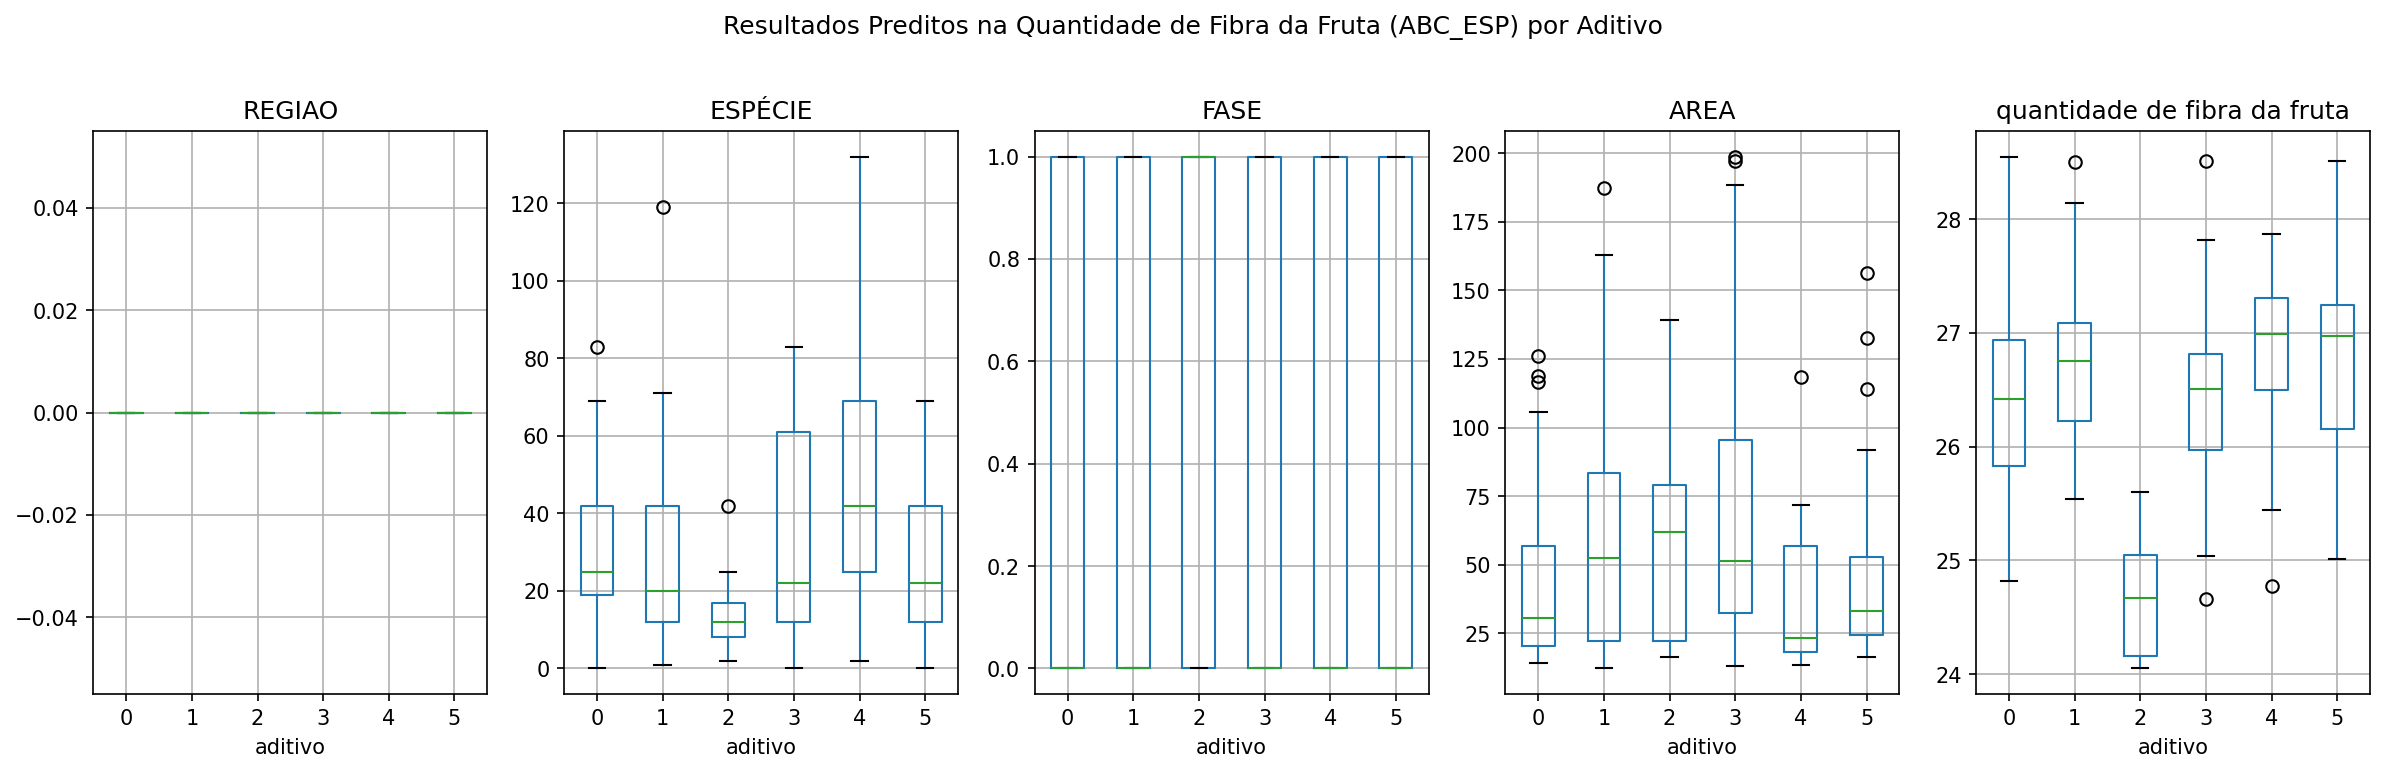


--- Resumo dos Resultados Preditos na ABC_ESP para Cada Aditivo ---

Resultados Preditos para o Aditivo 0:
  Média: 25.48
  Desvio Padrão: 0.63

Resultados Preditos para o Aditivo 1:
  Média: 25.96
  Desvio Padrão: 0.83

Resultados Preditos para o Aditivo 2:
  Média: 25.25
  Desvio Padrão: 0.55

Resultados Preditos para o Aditivo 3:
  Média: 25.45
  Desvio Padrão: 0.54

Resultados Preditos para o Aditivo 4:
  Média: 25.71
  Desvio Padrão: 0.65

Resultados Preditos para o Aditivo 5:
  Média: 25.65
  Desvio Padrão: 0.68


In [48]:
import matplotlib.pyplot as plt
import numpy as np
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# 1. Define a variável alvo y como sets['ABC_ESP']
y = sets['ABC_ESP']

# 2. Instancia um novo modelo DecisionTreeCounterfactual e o ajusta
dtcfsoma = DecisionTreeCounterfactual(save_explanatory=True)
dtcfsoma.fit(X, W, y)

# 3. Prevê contrafactuais
counterfactuals = dtcfsoma.predict(X)

# 4. Seleciona a primeira linha de X como test_sample e usa o método explain() do modelo
test_sample = X.iloc[[0]]
comparables_table = dtcfsoma.explain(test_sample)

# 5. Renomeia as colunas 'W' para 'aditivo' e 'y' para 'quantidade de fibra da fruta'
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'quantidade de fibra da fruta'})

# 6. Gera boxplots
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('quantidade de fibra da fruta','aditivo', ax=ax[4])
# 7. Adiciona um título geral à figura dos boxplots e mostra o gráfico
plt.suptitle('Resultados Preditos na Quantidade de Fibra da Fruta (ABC_ESP) por Aditivo', y=1.02)
plt.tight_layout()
plt.show()

# 8. Armazena os resultados previstos para cada aditivo (0 a 5)
sets['predicted_abc_esp_add_0'] = counterfactuals['y_hat'][0].values
sets['predicted_abc_esp_add_1'] = counterfactuals['y_hat'][1].values
sets['predicted_abc_esp_add_2'] = counterfactuals['y_hat'][2].values
sets['predicted_abc_esp_add_3'] = counterfactuals['y_hat'][3].values
sets['predicted_abc_esp_add_4'] = counterfactuals['y_hat'][4].values
sets['predicted_abc_esp_add_5'] = counterfactuals['y_hat'][5].values

# 9. Itera sobre as novas colunas e imprime a média e o desvio padrão
print('\n--- Resumo dos Resultados Preditos na ABC_ESP para Cada Aditivo ---')
for i in range(6):
    col_name = f'predicted_abc_esp_add_{i}'
    print(f"\nResultados Preditos para o Aditivo {i}:")
    print(f"  Média: {sets[col_name].mean():.2f}")
    print(f"  Desvio Padrão: {sets[col_name].std():.2f}")

## Analisar Resultados Preditos para Produtividade (ABE_ESP)

### Subtask:
Configurar e executar o modelo DecisionTreeCounterfactual para ABE_ESP como variável de resultado. O código irá definir y para sets['ABE_ESP'], ajustar o modelo, prever contrafactuais, gerar boxplots para visualização e imprimir a média e o desvio padrão dos resultados preditos para cada aditivo (0-5).


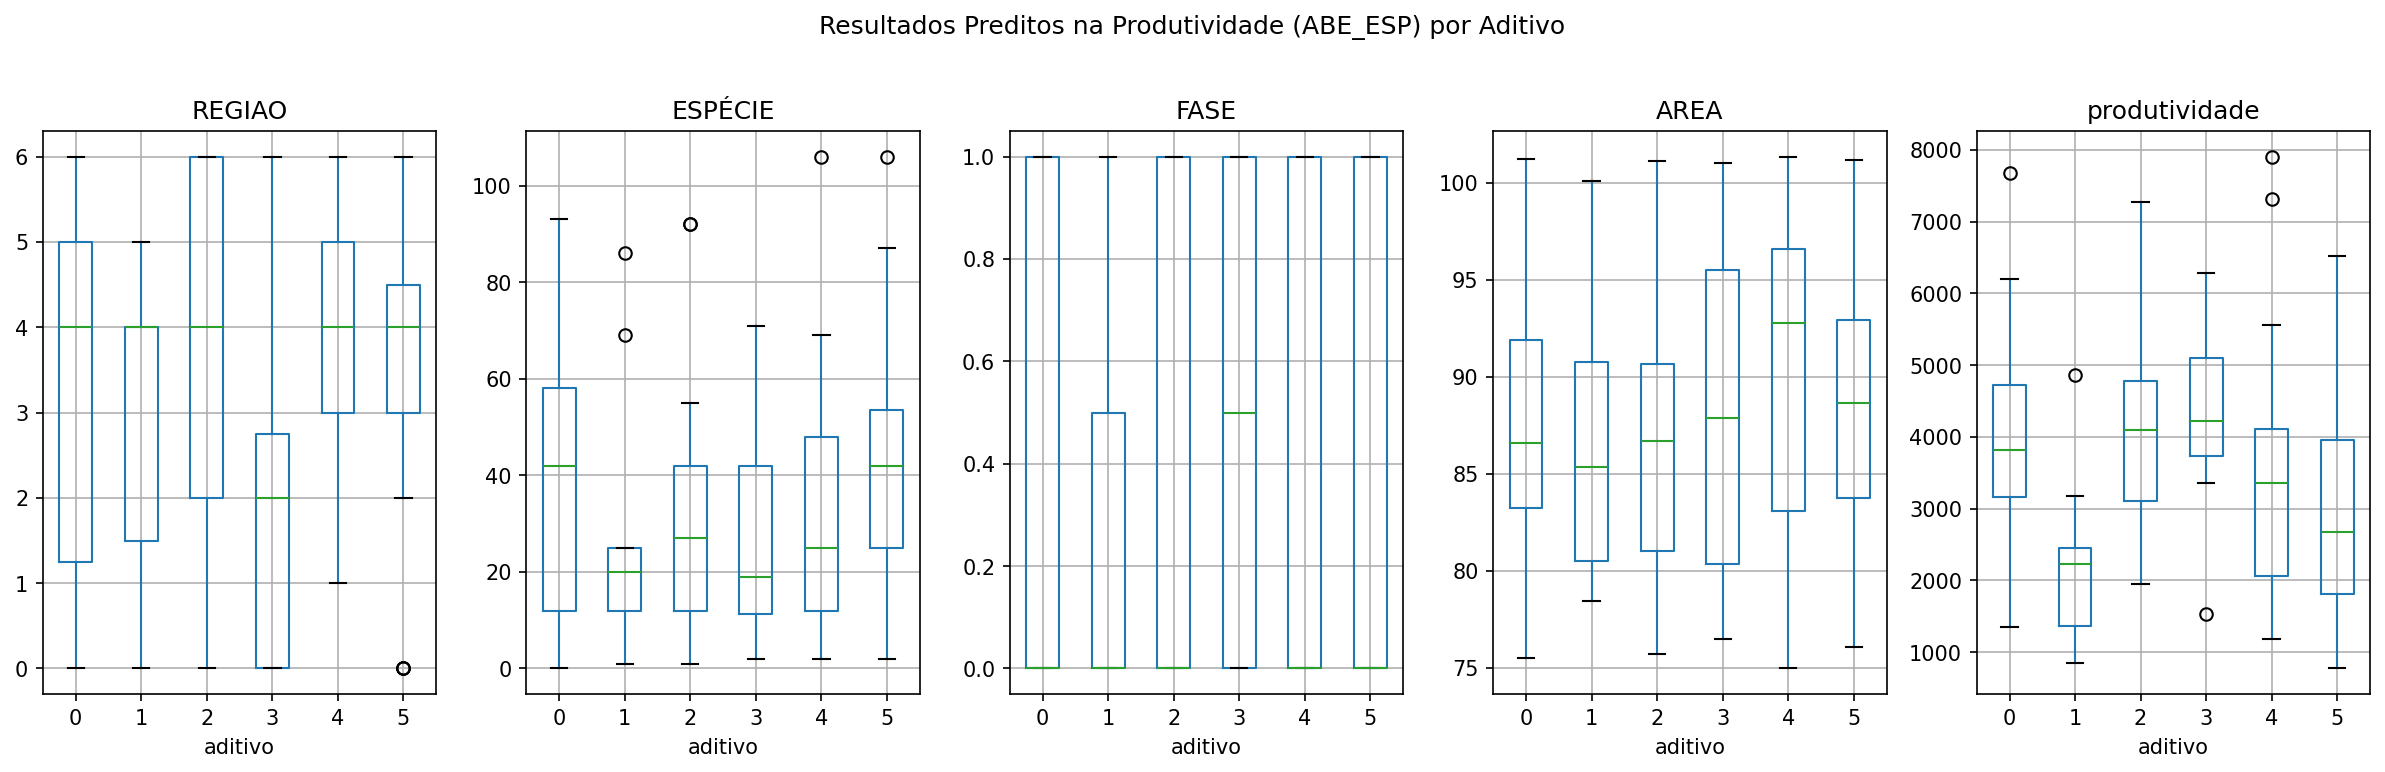


--- Resumo dos Resultados Preditos na ABE_ESP para Cada Aditivo ---

Resultados Preditos para o Aditivo 0:
  Média: 3187.56
  Desvio Padrão: 3195.87

Resultados Preditos para o Aditivo 1:
  Média: 2528.36
  Desvio Padrão: 2340.38

Resultados Preditos para o Aditivo 2:
  Média: 3192.13
  Desvio Padrão: 3182.35

Resultados Preditos para o Aditivo 3:
  Média: 3375.98
  Desvio Padrão: 3472.03

Resultados Preditos para o Aditivo 4:
  Média: 2684.28
  Desvio Padrão: 2685.05

Resultados Preditos para o Aditivo 5:
  Média: 2918.44
  Desvio Padrão: 2896.67


In [49]:
import matplotlib.pyplot as plt
import numpy as np
from cfml_tools.cfml_tools.tree import DecisionTreeCounterfactual

# 1. Define a variável alvo y como sets['ABE_ESP']
y = sets['ABE_ESP']

# 2. Instancia um novo modelo DecisionTreeCounterfactual e o ajusta
dtcf_abe = DecisionTreeCounterfactual(save_explanatory=True)
dtcf_abe.fit(X, W, y)

# 3. Prevê contrafactuais
counterfactuals = dtcf_abe.predict(X)

# 4. Seleciona a primeira linha de X como test_sample e usa o método explain() do modelo
test_sample = X.iloc[[0]]
comparables_table = dtcf_abe.explain(test_sample)

# 5. Renomeia as colunas 'W' para 'aditivo' e 'y' para 'produtividade'
comparables_table = comparables_table.rename(columns={'W':'aditivo','y':'produtividade'})

# 6. Gera boxplots
fig, ax = plt.subplots(1, 5, figsize=(16, 5), dpi=150)
comparables_table.boxplot('REGIAO','aditivo', ax=ax[0])
comparables_table.boxplot('ESPÉCIE','aditivo', ax=ax[1])
comparables_table.boxplot('FASE','aditivo', ax=ax[2])
comparables_table.boxplot('AREA','aditivo', ax=ax[3])
comparables_table.boxplot('produtividade','aditivo', ax=ax[4])
# 7. Adiciona um título geral à figura dos boxplots e mostra o gráfico
plt.suptitle('Resultados Preditos na Produtividade (ABE_ESP) por Aditivo', y=1.02)
plt.tight_layout()
plt.show()

# 8. Armazena os resultados previstos para cada aditivo (0 a 5)
sets['predicted_abe_esp_add_0'] = counterfactuals['y_hat'][0].values
sets['predicted_abe_esp_add_1'] = counterfactuals['y_hat'][1].values
sets['predicted_abe_esp_add_2'] = counterfactuals['y_hat'][2].values
sets['predicted_abe_esp_add_3'] = counterfactuals['y_hat'][3].values
sets['predicted_abe_esp_add_4'] = counterfactuals['y_hat'][4].values
sets['predicted_abe_esp_add_5'] = counterfactuals['y_hat'][5].values

# 9. Itera sobre as novas colunas e imprime a média e o desvio padrão
print('\n--- Resumo dos Resultados Preditos na ABE_ESP para Cada Aditivo ---')
for i in range(6):
    col_name = f'predicted_abe_esp_add_{i}'
    print(f"\nResultados Preditos para o Aditivo {i}:")
    print(f"  Média: {sets[col_name].mean():.2f}")
    print(f"  Desvio Padrão: {sets[col_name].std():.2f}")

## Resumo:

### Principais Descobertas da Análise de Dados

*   **Efeitos Causais na Quantidade de Fibra da Fruta (ABC_ESP) Análise**:
    *   O modelo `DecisionTreeCounterfactual` foi aplicado com `ABC_ESP` como variável alvo.
    *   As quantidades médias de fibra preditas para cada aditivo são:
        *   Aditivo 0: 25.48 (desvio padrão: 0.63)
        *   Aditivo 1: 25.96 (desvio padrão: 0.83)
        *   Aditivo 2: 25.25 (desvio padrão: 0.55)
        *   Aditivo 3: 25.45 (desvio padrão: 0.54)
        *   Aditivo 4: 25.71 (desvio padrão: 0.65)
        *   Aditivo 5: 25.65 (desvio padrão: 0.68)
    *   O Aditivo 1 apresentou a maior quantidade média de fibra predita (25.96), enquanto o Aditivo 2 apresentou a menor (25.25).

*   **Efeitos Causais na Produtividade (ABE_ESP) Análise**:
    *   O modelo `DecisionTreeCounterfactual` foi aplicado com `ABE_ESP` como variável alvo.
    *   As produtividades médias preditas para cada aditivo são:
        *   Aditivo 0: 3187.56 (desvio padrão: 3195.87)
        *   Aditivo 1: 2528.36 (desvio padrão: 2340.38)
        *   Aditivo 2: 3192.13 (desvio padrão: 3182.35)
        *   Aditivo 3: 3375.98 (desvio padrão: 3472.03)
        *   Aditivo 4: 2684.28 (desvio padrão: 2685.05)
        *   Aditivo 5: 2918.44 (desvio padrão: 2896.67)
    *   O Aditivo 3 resultou na maior produtividade média predita (3375.98), enquanto o Aditivo 1 resultou na menor (2528.36).

*   Para `ABC_ESP` e `ABE_ESP`, foram gerados boxplots para visualizar a distribuição das características relevantes e da variável de resultado entre os diferentes aditivos.

### Insights ou Próximos Passos

*   **Análise de Compensação**: O Aditivo 1 otimiza a quantidade de fibra da fruta, mas reduz significativamente a produtividade. Por outro lado, o Aditivo 3 maximiza a produtividade, mas não leva à maior quantidade de fibra. Uma decisão abrangente deve considerar a importância relativa dessas duas métricas.
*   **Investigar Aditivos 1 e 3**: Uma análise mais aprofundada deve se concentrar nos Aditivos 1 (maior fibra, menor produtividade) e 3 (maior produtividade). Isso pode envolver o exame das condições ou características específicas que impulsionam esses resultados extremos para entender se uma abordagem equilibrada ou uma aplicação especializada é viável.